In [ ]:
import pandas as pd

# Load the raw dataset
df = pd.read_csv('../data/raw/zomato-dataset.csv')

# Display the first 5 rows
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [14]:
# Check the number of rows, columns, and data types
df.info()

# Check for missing (null) values in each column
df.isnull().sum()

# Get summary statistics of numerical columns
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  str    
 1   Delivery_person_ID           45584 non-null  str    
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  str    
 9   Time_Orderd                  43853 non-null  str    
 10  Time_Order_picked            45584 non-null  str    
 11  Weather_conditions           44968 non-null  str    
 12  Road_traffic_density         44983 non-null  str    
 13  Vehicle_condition          

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min)
count,43730.000000,43676.000000,45584.000000,45584.000000,45584.000000,45584.000000,45584.000000,44591.000000,45584.000000
mean,29.566911,4.633774,17.017948,70.229684,17.465480,70.844161,1.023385,0.744635,26.293963
std,5.815064,0.334744,8.185674,22.885575,7.335562,21.120578,0.839055,0.572510,9.384298
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.551440,75.897963,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


In [15]:
# 1. Fill missing numerical values with the Median
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median())
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median())
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(df['multiple_deliveries'].median())

# 2. Fill missing categorical values with the Mode (most frequent value)
df['Weather_conditions'] = df['Weather_conditions'].fillna(df['Weather_conditions'].mode()[0])
df['Road_traffic_density'] = df['Road_traffic_density'].fillna(df['Road_traffic_density'].mode()[0])
df['Festival'] = df['Festival'].fillna(df['Festival'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])

# 3. Drop rows where 'Time_Orderd' is missing (we can't guess exact timestamps safely)
df.dropna(subset=['Time_Orderd'], inplace=True)

# Verify the cleaning worked (should print 0 for all)
print(df.isnull().sum())

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
dtype: int64


/tmp/ipykernel_209013/864240652.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Road_traffic_density', y='Time_taken (min)', data=df,


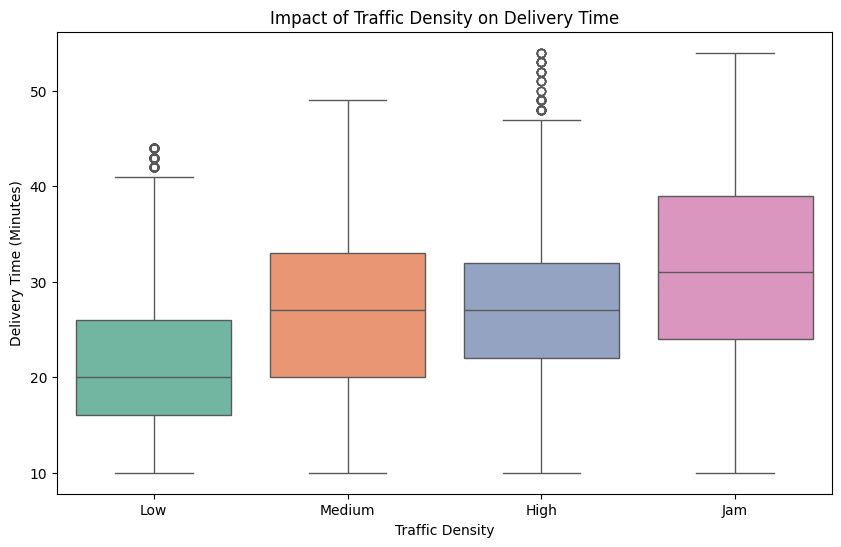

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Road_traffic_density', y='Time_taken (min)', data=df, 
            order=['Low', 'Medium', 'High', 'Jam'], palette='Set2')
plt.title('Impact of Traffic Density on Delivery Time')
plt.xlabel('Traffic Density')
plt.ylabel('Delivery Time (Minutes)')
plt.show()

/tmp/ipykernel_209013/846509977.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weather_conditions', y='Time_taken (min)', data=df, palette='coolwarm')


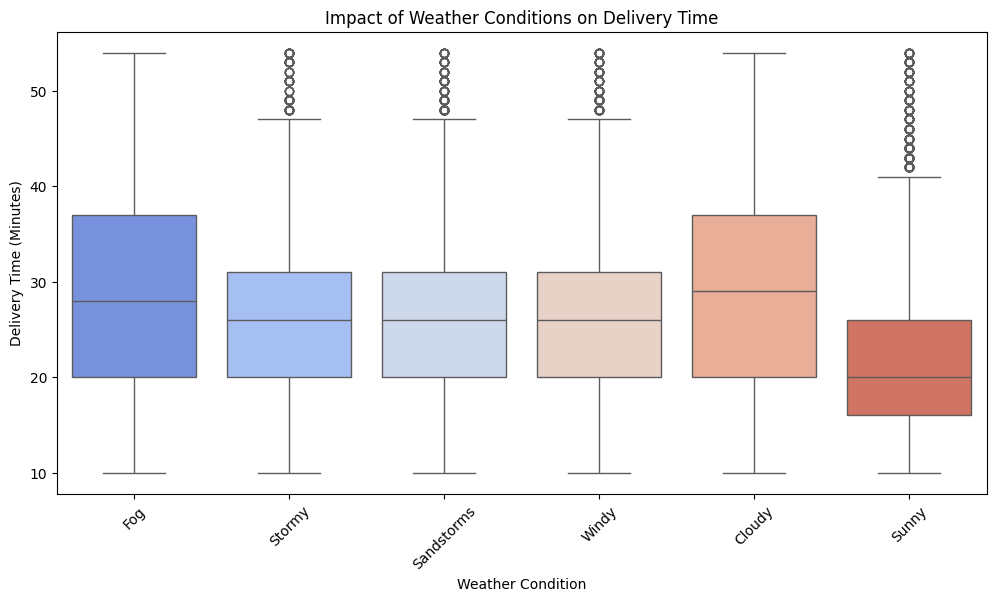

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Weather_conditions', y='Time_taken (min)', data=df, palette='coolwarm')
plt.title('Impact of Weather Conditions on Delivery Time')
plt.xlabel('Weather Condition')
plt.ylabel('Delivery Time (Minutes)')
plt.xticks(rotation=45)
plt.show()

<Figure size 1000x600 with 0 Axes>

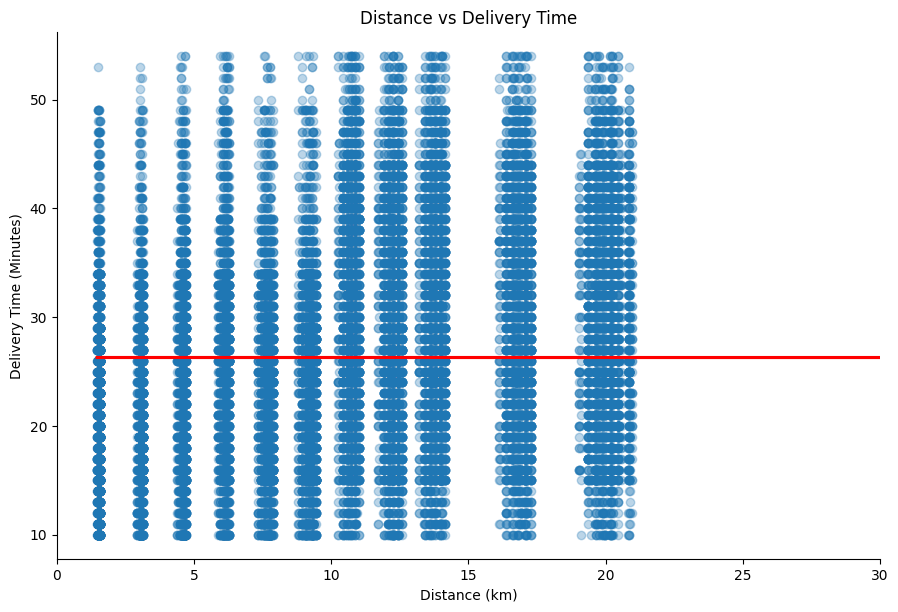

In [21]:
plt.figure(figsize=(10, 6))
sns.lmplot(x='Distance_km', y='Time_taken (min)', data=df, 
           scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, height=6, aspect=1.5)
plt.title('Distance vs Delivery Time')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (Minutes)')

# Filter out extreme anomalies in distance (e.g. distance > 50km is likely an error)
plt.xlim(0, 30) 
plt.show()